In [1]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt

from SRIM import SRIM

# Make bigger fonts
plt.rc('font', size=12)

# Define reaction variables
M0 = 1.0078250 # amu projectile
M1 = 18.998403 # amu target

q1 = 1.0 # charge of projectile
q2 = 9.0 # charge of target

mu = M0 * M1 / ( M0 + M1 ) # reduced mass
q = q1 * q2 # charge of reaction

# Conversion factors
q_c = 1.60217662e-19 # C

In [2]:
# Read the element stopping data
H_in_F = SRIM( "stopping/H_in_F.stop" )
H_in_H = SRIM( "stopping/H_in_H.stop" )
H_in_Fe = SRIM( "stopping/H_in_Fe.stop" )
H_in_Ta = SRIM( "stopping/H_in_Ta.stop" )
H_in_Ca = SRIM( "stopping/H_in_Ca.stop" )

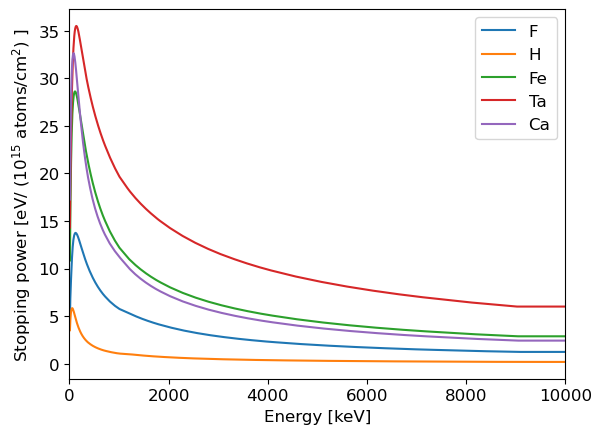

In [3]:
# Plot the stopping powers
energies = np.linspace( 10, 10000, 10000 )

data_F = [ H_in_F.eval( energy ) for energy in energies ]
data_H = [ H_in_H.eval( energy ) for energy in energies ]
data_Fe = [ H_in_Fe.eval( energy ) for energy in energies ]
data_Ta = [ H_in_Ta.eval( energy ) for energy in energies ]
data_Ca = [ H_in_Ca.eval( energy ) for energy in energies ]

plt.plot( energies, data_F, label="F" )
plt.plot( energies, data_H, label="H" )
plt.plot( energies, data_Fe, label="Fe" )
plt.plot( energies, data_Ta, label="Ta" )
plt.plot( energies, data_Ca, label="Ca" )

plt.xlim( 0, 10000 )

plt.xlabel( "Energy [keV]" )
plt.ylabel( r"Stopping power [eV/ (10$^{15}$ atoms/cm$^{2}$) ]" )

plt.legend()

plt.show()

In [4]:
# Get the effective stopping power for CaF2
def effective_stopping_CaF2( energy, n_inactive=1, n_active=2 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ca.eval( energy )

# Get the effective stopping power for F implanted in Fe
def effective_stopping_Fe( energy, n_inactive=1, n_active=3 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Fe.eval( energy )

# Get the effective stopping power for F implanted in Ta
def effective_stopping_Ta( energy, n_inactive=1, n_active=5 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ta.eval( energy )

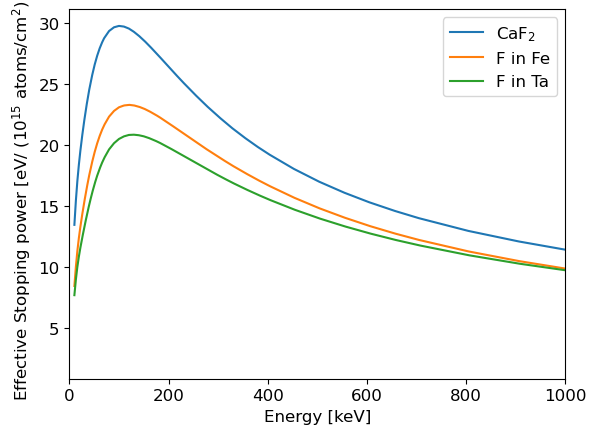

In [5]:
# Plot the effective stopping power for CaF2
energies = np.linspace( 10, 10000, 10000 )

data_CaF2 = [ effective_stopping_CaF2( energy ) for energy in energies ]
data_Fe = [ effective_stopping_Fe( energy ) for energy in energies ]
data_Ta = [ effective_stopping_Ta( energy ) for energy in energies ]

plt.plot( energies, data_CaF2, label=r"CaF$_{2}$" )
plt.plot( energies, data_Fe, label=r"F in Fe" )
plt.plot( energies, data_Ta, label=r"F in Ta" )

plt.xlim( 0, 1000 )

plt.xlabel( "Energy [keV]" )
plt.ylabel( r"Effective Stopping power [eV/ (10$^{15}$ atoms/cm$^{2}$) ]" )

plt.legend()

plt.show()

In [6]:
def de_broglie( m0, m1, e_lab ):
    return 4.125 * pow( 10, -18 ) * pow( (m0 + m1) / m1, 2 ) / m0 / e_lab

In [7]:
eff = 0.689 # From simulation
omega_gamma = 0.015 # eV
energy = 214.8 * 1e3  # eV
stop_CaF = effective_stopping_CaF2( energy ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)
stop_Fe = effective_stopping_Fe( energy, 10, 1 ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)
stop_Ta = effective_stopping_Ta( energy, 14, 1 ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)

y_CaF = de_broglie( M0, M1, energy ) * omega_gamma / stop_CaF / q_c / 1e6 * eff
y_Fe = de_broglie( M0, M1, energy ) * omega_gamma / stop_Fe / q_c / 1e6 * eff
y_Ta = de_broglie( M0, M1, energy ) * omega_gamma / stop_Ta / q_c / 1e6 * eff

print( "y_CaF2 = ", y_CaF )
print( "y_Fe = ", y_Fe )
print( "y_Ta = ", y_Ta )

y_CaF2 =  555.7658532121056
y_Fe =  45.35977087432824
y_Ta =  15.977396933532091


In [8]:
eff = 0.689 # From simulation
omega_gamma = 0.015 # eV
energy = 227.9 * 1e3  # eV
stop_CaF = effective_stopping_CaF2( energy ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)
stop_Fe = effective_stopping_Fe( energy, 10, 1 ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)
stop_Ta = effective_stopping_Ta( energy, 14, 1 ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)

y_CaF = de_broglie( M0, M1, energy ) * omega_gamma / stop_CaF / q_c / 1e6 * eff
y_Fe = de_broglie( M0, M1, energy ) * omega_gamma / stop_Fe / q_c / 1e6 * eff
y_Ta = de_broglie( M0, M1, energy ) * omega_gamma / stop_Ta / q_c / 1e6 * eff

print( "y_CaF2 = ", y_CaF )
print( "y_Fe = ", y_Fe )
print( "y_Ta = ", y_Ta )

y_CaF2 =  523.8196808686279
y_Fe =  42.7524299421049
y_Ta =  15.058994564820946


In [9]:
eff = 0.0044 # From simulations in far geometry
omega_gamma = 24.3 # eV
energy = 323.9 * 1e3  # eV
stop_CaF = effective_stopping_CaF2( energy ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)
stop_Fe = effective_stopping_Fe( energy, 10, 1 ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)
stop_Ta = effective_stopping_Ta( energy, 14, 1 ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)

y_CaF = de_broglie( M0, M1, energy ) * omega_gamma / stop_CaF / q_c / 1e6 * eff
y_Fe = de_broglie( M0, M1, energy ) * omega_gamma / stop_Fe / q_c / 1e6 * eff
y_Ta = de_broglie( M0, M1, energy ) * omega_gamma / stop_Ta / q_c / 1e6 * eff

print( "y_CaF2 = ", y_CaF )
print( "y_Fe = ", y_Fe )
print( "y_Ta = ", y_Ta )

y_CaF2 =  3812.9723671826046
y_Fe =  311.2021941001478
y_Ta =  109.61697746445672


In [23]:
eff = 0.19 # From simulation
omega_gamma = 2.19e-5 # eV
energy = 225 * 1e3  # eV
stop_CaF = effective_stopping_CaF2( energy ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)
stop_Fe = effective_stopping_Fe( energy, 10, 1 ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)
stop_Ta = effective_stopping_Ta( energy, 14, 1 ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)

y_CaF = de_broglie( M0, M1, energy ) * omega_gamma / stop_CaF / q_c / 1e6 * eff
y_Fe = de_broglie( M0, M1, energy ) * omega_gamma / stop_Fe / q_c / 1e6 * eff
y_Ta = de_broglie( M0, M1, energy ) * omega_gamma / stop_Ta / q_c / 1e6 * eff

print( "y_CaF2 = ", y_CaF )
print( "y_Fe = ", y_Fe )
print( "y_Ta = ", y_Ta )

# 6e-3 Riccardo's result

y_CaF2 =  0.21361456127648443
y_Fe =  0.017434514011467204
y_Ta =  0.006141083725405034


In [30]:
eff = 0.19 # From simulation
omega_gamma = 3.2e-7 # eV
energy = 213 * 1e3  # eV
stop_CaF = effective_stopping_CaF2( energy ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)
stop_Fe = effective_stopping_Fe( energy, 10, 1 ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)
stop_Ta = effective_stopping_Ta( energy, 14, 1 ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)

y_CaF = de_broglie( M0, M1, energy ) * omega_gamma / stop_CaF / q_c / 1e6 * eff
y_Fe = de_broglie( M0, M1, energy ) * omega_gamma / stop_Fe / q_c / 1e6 * eff
y_Ta = de_broglie( M0, M1, energy ) * omega_gamma / stop_Ta / q_c / 1e6 * eff

print( "y_CaF2 = ", y_CaF )
print( "y_Fe = ", y_Fe )
print( "y_Ta = ", y_Ta )

# 9e-5 Riccardo's result

y_CaF2 =  0.003297157033015387
y_Fe =  0.00026910305246331784
y_Ta =  9.478809531784733e-05
